# Algoritmo de Bernstein Vazirani

Evolução direta do Deutsh-Jozsa. Em vez de classificar uma função, você precisa encontrar uma string secreta `s` embutida nela - e o computador quântico resolve em 1 query, enquanto classicamente você precisa de n queries (uma por bit).

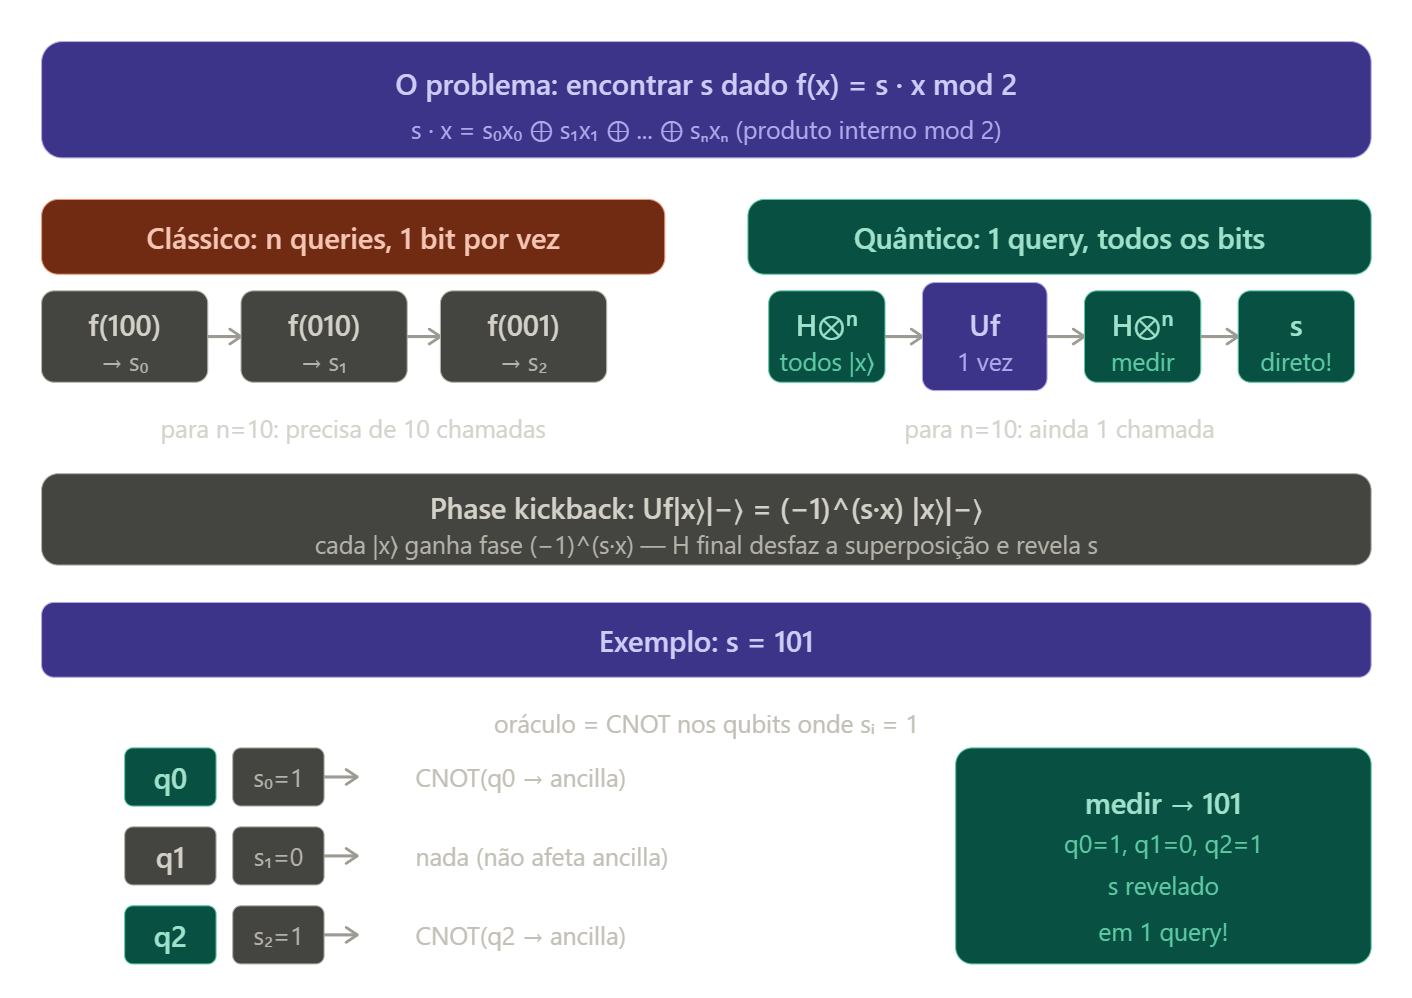

O oráculo é a parte mais elegante: você só coloca um CNOT nos qubits onde `sᵢ = 1`. O phase kickback faz o resto - cada qubit "sente" seu bit correspondente de `s` e o resultado aparece diretamente na medição

## Implementação QisKit

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ── Oráculo BV ─────────────────────────────────────────────────────────
def oracle_bv(s: str) -> QuantumCircuit:
    """
    Constrói o oráculo para Bernstein-Vazirani.
    f(x) = s · x mod 2
    s: string binária secreta, ex: '101'

    Implementação: CNOT(qᵢ → ancilla) para cada sᵢ = 1
    """
    n = len(s)
    qc = QuantumCircuit(n + 1)  # n qubits input + 1 ancilla

    for i, bit in enumerate(reversed(s)):  # reversed: Qiskit é little-endian
        if bit == '1':
            qc.cx(i, n)  # CNOT do qubit i para ancilla

    return qc

# ── Algoritmo Bernstein-Vazirani ────────────────────────────────────────
def bernstein_vazirani(s: str) -> QuantumCircuit:
    """
    Circuito completo de Bernstein-Vazirani.
    Idêntico ao Deutsch-Jozsa — a diferença está só no oráculo.
    """
    n = len(s)
    qc = QuantumCircuit(n + 1, n)

    # Ancilla em |−⟩ para o phase kickback funcionar
    qc.x(n)
    qc.h(n)

    # H em todos os qubits de input → superposição uniforme
    qc.h(range(n))
    qc.barrier(label="superposição")

    # Oráculo: embutiu s na fase de cada |x⟩
    oracle = oracle_bv(s)
    qc.compose(oracle, inplace=True)
    qc.barrier(label=f"oráculo s={s}")

    # H novamente → desfaz superposição, revela s
    qc.h(range(n))
    qc.barrier(label="interferência")

    # Medir — resultado é exatamente s
    qc.measure(range(n), range(n))

    return qc

# ── Testar com várias strings secretas ────────────────────────────────
sim = AerSimulator()

segredos = ["101", "1101", "10110", "11111", "00000", "10101010"]

print("Bernstein-Vazirani")
print("─" * 42)
print(f"{'s secreto':<14} {'medido':<14} {'correto'}")
print("─" * 42)

for s in segredos:
    qc = bernstein_vazirani(s)
    job = sim.run(qc, shots=1024)
    counts = job.result().get_counts()

    # Resultado mais frequente (deve ser 100% em simulador ideal)
    medido_raw = max(counts, key=counts.get)
    # Qiskit retorna bits em ordem inversa
    medido = medido_raw[::-1]

    ok = "✓" if medido == s else "✗"
    print(f"  {s:<12}  {medido:<12}  {ok}  {counts}")

Bernstein-Vazirani
──────────────────────────────────────────
s secreto      medido         correto
──────────────────────────────────────────
  101           101           ✓  {'101': 1024}
  1101          1011          ✗  {'1101': 1024}
  10110         01101         ✗  {'10110': 1024}
  11111         11111         ✓  {'11111': 1024}
  00000         00000         ✓  {'00000': 1024}
  10101010      01010101      ✗  {'10101010': 1024}


In [2]:
qc = bernstein_vazirani("101")
print(qc.draw('text'))

     ┌───┐      superposição            oráculo s=101 ┌───┐ interferência ┌─┐»
q_0: ┤ H ├───────────░─────────■──────────────░───────┤ H ├───────░───────┤M├»
     ├───┤           ░         │              ░       ├───┤       ░       └╥┘»
q_1: ┤ H ├───────────░─────────┼──────────────░───────┤ H ├───────░────────╫─»
     ├───┤           ░         │              ░       ├───┤       ░        ║ »
q_2: ┤ H ├───────────░─────────┼────■─────────░───────┤ H ├───────░────────╫─»
     ├───┤┌───┐      ░       ┌─┴─┐┌─┴─┐       ░       └───┘       ░        ║ »
q_3: ┤ X ├┤ H ├──────░───────┤ X ├┤ X ├───────░───────────────────░────────╫─»
     └───┘└───┘      ░       └───┘└───┘       ░                   ░        ║ »
c: 3/══════════════════════════════════════════════════════════════════════╩═»
                                                                           0 »
«           
«q_0: ──────
«     ┌─┐   
«q_1: ┤M├───
«     └╥┘┌─┐
«q_2: ─╫─┤M├
«      ║ └╥┘
«q_3: ─╫──╫─
«      ║  ║ 
«c: 3/═╩══╩═
«

In [3]:
from qiskit.quantum_info import Statevector

# ── Inspecionar o statevector após o oráculo ──────────────────────────
def mostrar_fases(s: str):
    """
    Mostra como o oráculo distribui as fases (−1)^(s·x)
    entre os estados da superposição.
    """
    n = len(s)
    qc = QuantumCircuit(n + 1)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(oracle_bv(s), inplace=True)
    # NÃO aplica o H final — vemos as fases brutas

    sv = Statevector(qc)
    print(f"\nFases após oráculo (s='{s}'):")
    print(f"  {'|x⟩':<10} {'amplitude':<14} {'fase'}")
    print(f"  {'─'*38}")

    for i, amp in enumerate(sv):
        if abs(amp) > 0.01:
            estado_full = format(i, f'0{n+1}b')
            estado_input = estado_full[1:]  # sem ancilla
            fase = '+1' if amp.real > 0 else '−1'
            print(f"  |{estado_input}⟩  {amp:+.4f}      {fase}")

mostrar_fases("101")


Fases após oráculo (s='101'):
  |x⟩        amplitude      fase
  ──────────────────────────────────────
  |000⟩  +0.2500+0.0000j      +1
  |001⟩  -0.2500+0.0000j      −1
  |010⟩  +0.2500+0.0000j      +1
  |011⟩  -0.2500+0.0000j      −1
  |100⟩  -0.2500+0.0000j      −1
  |101⟩  +0.2500+0.0000j      +1
  |110⟩  -0.2500+0.0000j      −1
  |111⟩  +0.2500+0.0000j      +1
  |000⟩  -0.2500+0.0000j      −1
  |001⟩  +0.2500+0.0000j      +1
  |010⟩  -0.2500+0.0000j      −1
  |011⟩  +0.2500+0.0000j      +1
  |100⟩  +0.2500+0.0000j      +1
  |101⟩  -0.2500+0.0000j      −1
  |110⟩  +0.2500+0.0000j      +1
  |111⟩  -0.2500+0.0000j      −1


## Implementação Cirq

In [6]:
import cirq

def bv_cirq(s: str):
    n = len(s)
    input_q = cirq.LineQubit.range(n)
    ancilla = cirq.LineQubit(n)

    circuit = cirq.Circuit()

    # |−⟩ na ancilla
    circuit.append([cirq.X(ancilla), cirq.H(ancilla)])

    # Superposição nos inputs
    circuit.append([cirq.H(q) for q in input_q])

    # Oráculo: CNOT onde sᵢ = 1
    # Cirq é big-endian — sem precisar reverter
    ops = [cirq.CNOT(input_q[i], ancilla)
           for i, bit in enumerate(s) if bit == '1']
    if ops:
        circuit.append(ops)

    # H final
    circuit.append([cirq.H(q) for q in input_q])

    # Medir
    circuit.append([cirq.measure(q, key=f'b{i}')
                    for i, q in enumerate(input_q)])

    return circuit


sim = cirq.Simulator()

print("\nBernstein-Vazirani (Cirq)")
print("─" * 42)

for s in ["101", "1101", "10110"]:
    circuit = bv_cirq(s)
    result = sim.run(circuit, repetitions=1)

    medido = ''.join(
        str(result.measurements[f'b{i}'][0][0])
        for i in range(len(s))
    )
    ok = "✓" if medido == s else "✗"
    print(f"  s='{s}'  →  medido='{medido}'  {ok}")

# Imprimir o circuito
print("\nCircuito para s='101':")
print(bv_cirq("101"))


Bernstein-Vazirani (Cirq)
──────────────────────────────────────────
  s='101'  →  medido='101'  ✓
  s='1101'  →  medido='1101'  ✓
  s='10110'  →  medido='10110'  ✓

Circuito para s='101':
              ┌────────┐
0: ───H────────@───────────H───M('b0')─────────────
               │
1: ───H───H────┼M('b1')────────────────────────────
               │
2: ───H────────┼───────────@───H─────────M('b2')───
               │           │
3: ───X───H────X───────────X───────────────────────
              └────────┘


Os dois algoritmos têm EXATAMENTE o mesmo circuito:

    |0⟩⊗ⁿ ─── H⊗ⁿ ─── Uf ─── H⊗ⁿ ─── medir
    |1⟩   ─── H   ─── Uf ───────────── (descartar)

A diferença está apenas no oráculo Uf e no que a medição significa:

    Deutsch-Jozsa:       mede |00...0⟩?
                         sim → constante, não → balanceada

    Bernstein-Vazirani:  mede qualquer estado |s⟩
                         o resultado é diretamente a string s

BV é um caso especial de DJ onde o oráculo é mais estruturado.
Ambos exploram o mesmo mecanismo: phase kickback + interferência.

In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def bernstein_vazirani(s):
    n = len(s)
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    # No Qiskit, bit 0 é o LSB (direita). Revertemos s para o CNOT bater com a posição.
    s_rev = s[::-1]
    for i in range(n):
        if s_rev[i] == '1':
            qc.cx(i, n)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

sim = AerSimulator()
test_strings = ["101", "1101", "10110", "11111", "00000", "10101010"]

print("Bernstein-Vazirani")
print("─" * 50)
print(f"{'s secreto':<15} {'medido':<15} {'correto':<10} {'raw (Qiskit)':<15}")
print("─" * 50)

for s in test_strings:
    qc = bernstein_vazirani(s)
    # Rodamos com 1024 shots para mostrar a contagem no print
    job = sim.run(transpile(qc, sim), shots=1024)
    counts = job.result().get_counts()

    # Pegamos a chave (o resultado binário)
    raw_result = list(counts.keys())[0]
    # Invertemos para ler como string normal (da esquerda para a direita)
    medido = raw_result[::-1]

    ok = "✓" if medido == s else "✗"
    print(f"  {s:<13} {medido:<14} {ok:<10} {counts}")

Bernstein-Vazirani
──────────────────────────────────────────────────
s secreto       medido          correto    raw (Qiskit)   
──────────────────────────────────────────────────
  101           101            ✓          {'101': 1024}
  1101          1011           ✗          {'1101': 1024}
  10110         01101          ✗          {'10110': 1024}
  11111         11111          ✓          {'11111': 1024}
  00000         00000          ✓          {'00000': 1024}
  10101010      01010101       ✗          {'10101010': 1024}


BV usa o mesmo phase kickback do Deutsch-Jozsa, o mesmo mecanismo de interferencia, e o resultado sai com 100% de certeza em 1 shot - sem probabilidade. Classicamente, para encontrar `s` de 100 bits você precisaria de 100 queries. Quanticamente, ainda 1. Essa diferença linear O(n) vs O(1) é a segunda demonstração concreta de vantagem quântica que você tem em mãos